In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [6]:
reference_date = df["InvoiceDate"].max()

In [7]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

In [8]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [9]:
threshold = rfm["Recency"].quantile(0.75)

rfm["Churn"] = rfm["Recency"].apply(
    lambda x: 1 if x > threshold else 0
)

In [10]:
features = ["Recency", "Frequency", "Monetary"]

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [12]:
X = rfm[features]
y = rfm["Churn"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [15]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

In [16]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [17]:
importance_df

,Feature,Importance
0,Recency,0.876389
2,Monetary,0.065315
1,Frequency,0.058296


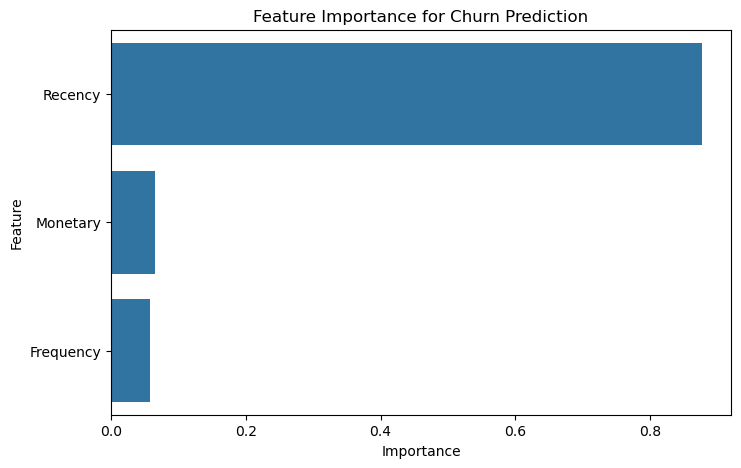

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance for Churn Prediction")

plt.show()

In [ ]:
""" 
Business Insight (İş İçgörüsü):
The model identified Recency as the most important feature for churn prediction.
This indicates that customers who have not purchased for a long time are significantly more likely to churn compared to customers with lower spending or purchase frequency.
Frequency and Monetary value contributed less to the prediction process, suggesting that recent customer activity is the strongest behavioral signal for retention risk.

Model, churn tahmini için en önemli değişkenin Recency olduğunu belirledi.
Bu sonuç, uzun süredir alışveriş yapmayan müşterilerin churn olma ihtimalinin, düşük harcama yapan veya daha az alışveriş yapan müşterilere göre çok daha yüksek olduğunu göstermektedir.-
Frequency ve Monetary değişkenleri tahmine daha az katkı sağlamıştır. Bu durum, müşteri kaybı riskini belirlemede en güçlü davranış sinyalinin müşterinin son alışveriş zamanı olduğunu göstermektedir.
"""